In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
from roofline import TransformerRoofline, Hardware
from cost import CostEst
from pim_search import cal_ts_baseline, cal_ts_pim

In [2]:
# Model
model = "GPT3.5" # model_list = ["M6-10B", "GPT3.5", "GPT4-8K", "Palm"]
ratio_p = 0.25 # ratio_p_list = [0.1, 0.25, 0.5, 0.75]
max_token = 4096 # max_token_list = [1024, 4096, 8192, 8192]
batchsize = 32 # batchsize_list = [8, 16, 32, 64, 128]

# hardware
comb_hard = {
    "Name":"A100*8+PIMv1*1", 
    "PRF":{"hard":"A100", "quant":8},  # V100, A100, H100
    "GNR-PRJ":{"hard":"A100", "quant":8}, 
    "GNR-ACT":{"hard":"PIMv1", "quant":1}, 
    "Assign":"PRF+GNR-PRJ, GNR-ACT"
}

# Search
max_token_list = [1024, 2048, 4096, 8192, 16384, 32768]
max_token_list = [1024, 2048, 3072, 4096, 6144, 8192, 12288, 16384, 24576, 32768]
batchsize_list = [1, 2, 4, 8, 16, 32, 64, 128, 256]
batchsize_list = [1, 2, 4, 8, 12, 16, 24, 32, 48, 64]

bw_list = []
cap_list = []
token_per_sec_list = []
token_per_sec_batch_list = []

In [3]:
for max_token in max_token_list:
    for batchsize in batchsize_list:
        print("Max_token: {}; Batchsize: {}".format(max_token, batchsize))
        comb_hard = {
            "Name":"A100*8+PIMv1*1", 
            "PRF":{"hard":"A100", "quant":8},  # V100, A100, H100
            "GNR-PRJ":{"hard":"A100", "quant":8}, 
            "GNR-ACT":{"hard":"PIMv1", "quant":1}, 
            "Assign":"PRF+GNR-PRJ, GNR-ACT"
        }
        bw, cap, token_per_sec, token_per_sec_batch = cal_ts_pim(comb_hard=comb_hard, batchsize=batchsize, model=model, ratio_p=ratio_p, max_token=max_token, ratio_token=0.8, fig=False)
        bw_list.append(bw)
        cap_list.append(cap)
        token_per_sec_list.append(token_per_sec)
        token_per_sec_batch_list.append(token_per_sec_batch)

Max_token: 1024; Batchsize: 1
Name: A100x8_baseline, token per sec: 50, token per sec per batch: 50

Model: GPT3.5, BatchSize: 1
Need XPU: 324.0GB | XPU capacity: 640GB
Need PIM: 4.5GB | PIM capacity: 4.5GB

The max perf is 49 token/s (TFLOPS: 503, BW: 503TB/s)
Max_token: 1024; Batchsize: 2
Name: A100x8_baseline, token per sec: 99, token per sec per batch: 49

Model: GPT3.5, BatchSize: 2
Need XPU: 324.0GB | XPU capacity: 640GB
Need PIM: 9.0GB | PIM capacity: 9.0GB

The max perf is 97 token/s (TFLOPS: 503, BW: 503TB/s)
Max_token: 1024; Batchsize: 4
Name: A100x8_baseline, token per sec: 194, token per sec per batch: 48

Model: GPT3.5, BatchSize: 4
Need XPU: 324.0GB | XPU capacity: 640GB
Need PIM: 18.0GB | PIM capacity: 18.0GB

The max perf is 190 token/s (TFLOPS: 503, BW: 503TB/s)
Max_token: 1024; Batchsize: 8
Name: A100x8_baseline, token per sec: 372, token per sec per batch: 46

Model: GPT3.5, BatchSize: 8
Need XPU: 324.0GB | XPU capacity: 640GB
Need PIM: 36.0GB | PIM capacity: 36.0GB


The max perf is 1120 token/s (TFLOPS: 503, BW: 503TB/s)
The 0.8 perf is 896 token/s (TFLOPS: 34.17, BW: 34.17TB/s)
Max_token: 3072; Batchsize: 48
Name: A100x8_baseline, token per sec: 1027, token per sec per batch: 21

Model: GPT3.5, BatchSize: 48
Need XPU: 324.0GB | XPU capacity: 640GB
Need PIM: 648.0GB | PIM capacity: 648.0GB

The max perf is 1462 token/s (TFLOPS: 503, BW: 503TB/s)
The 0.8 perf is 1169 token/s (TFLOPS: 43.60, BW: 43.60TB/s)
Max_token: 3072; Batchsize: 64
Name: A100x8_baseline, token per sec: 1148, token per sec per batch: 18

Model: GPT3.5, BatchSize: 64
Need XPU: 324.0GB | XPU capacity: 640GB
Need PIM: 864.0GB | PIM capacity: 864.0GB

The max perf is 1725 token/s (TFLOPS: 503, BW: 503TB/s)
The 0.8 perf is 1380 token/s (TFLOPS: 50.59, BW: 50.59TB/s)
Max_token: 4096; Batchsize: 1
Name: A100x8_baseline, token per sec: 49, token per sec per batch: 49

Model: GPT3.5, BatchSize: 1
Need XPU: 324.0GB | XPU capacity: 640GB
Need PIM: 18.0GB | PIM capacity: 18.0GB

The max per

The max perf is 357 token/s (TFLOPS: 503, BW: 503TB/s)
The 0.8 perf is 285 token/s (TFLOPS: 29.34, BW: 29.34TB/s)
Max_token: 8192; Batchsize: 12
Name: A100x8_baseline, token per sec: 326, token per sec per batch: 27

Model: GPT3.5, BatchSize: 12
Need XPU: 324.0GB | XPU capacity: 640GB
Need PIM: 432.0GB | PIM capacity: 432.0GB

The max perf is 508 token/s (TFLOPS: 503, BW: 503TB/s)
The 0.8 perf is 406 token/s (TFLOPS: 40.68, BW: 40.68TB/s)
Max_token: 8192; Batchsize: 16
Name: A100x8_baseline, token per sec: 376, token per sec per batch: 24

Model: GPT3.5, BatchSize: 16
Need XPU: 324.0GB | XPU capacity: 640GB
Need PIM: 576.0GB | PIM capacity: 576.0GB

The max perf is 645 token/s (TFLOPS: 503, BW: 503TB/s)
The 0.8 perf is 516 token/s (TFLOPS: 50.44, BW: 50.44TB/s)
Max_token: 8192; Batchsize: 24
Name: A100x8_baseline, token per sec: 445, token per sec per batch: 19

Model: GPT3.5, BatchSize: 24
Need XPU: 324.0GB | XPU capacity: 640GB
Need PIM: 864.0GB | PIM capacity: 864.0GB

The max perf 

The max perf is 1308 token/s (TFLOPS: 503, BW: 503TB/s)
The 0.8 perf is 1047 token/s (TFLOPS: 153.05, BW: 153.05TB/s)
Max_token: 16384; Batchsize: 64
Name: A100x8_baseline, token per sec: 322, token per sec per batch: 5

Model: GPT3.5, BatchSize: 64
Need XPU: 324.0GB | XPU capacity: 640GB
Need PIM: 4608.0GB | PIM capacity: 4608.0GB

The max perf is 1516 token/s (TFLOPS: 503, BW: 503TB/s)
The 0.8 perf is 1213 token/s (TFLOPS: 168.38, BW: 168.38TB/s)
Max_token: 24576; Batchsize: 1
Name: A100x8_baseline, token per sec: 42, token per sec per batch: 42

Model: GPT3.5, BatchSize: 1
Need XPU: 324.0GB | XPU capacity: 640GB
Need PIM: 108.0GB | PIM capacity: 108.0GB

The max perf is 49 token/s (TFLOPS: 503, BW: 503TB/s)
The 0.8 perf is 39 token/s (TFLOPS: 12.58, BW: 12.58TB/s)
Max_token: 24576; Batchsize: 2
Name: A100x8_baseline, token per sec: 71, token per sec per batch: 36

Model: GPT3.5, BatchSize: 2
Need XPU: 324.0GB | XPU capacity: 640GB
Need PIM: 216.0GB | PIM capacity: 216.0GB

The max p

In [4]:
# Convert to contourf
list_x, list_y = np.meshgrid(max_token_list, batchsize_list)
bw_list = np.array(bw_list)
bw_list = bw_list.reshape(len(max_token_list), len(batchsize_list))
bw_list = bw_list.T
cap_list = np.array(cap_list)
cap_list = cap_list.reshape(len(max_token_list), len(batchsize_list))
cap_list = cap_list.T

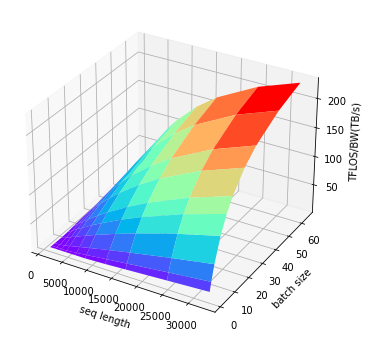

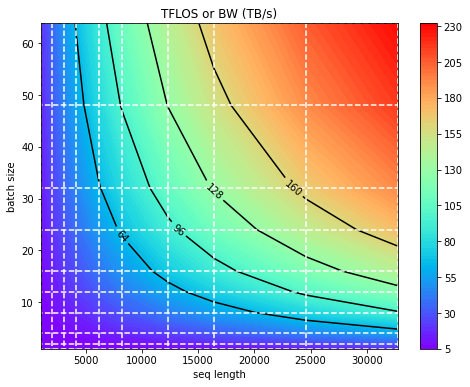

In [5]:
# TFLOS & BW
fig = plt.figure(figsize=(6,6))
ax3 = plt.axes(projection='3d')
ax3.plot_surface(list_x, list_y, bw_list, cmap='rainbow')
ax3.set_xlabel("seq length")
ax3.set_ylabel("batch size")
ax3.set_zlabel("TFLOS/BW(TB/s)")
plt.show()

plt.figure(figsize=(8,6))
line = [64, 96, 128, 160, 256]

cset = plt.contourf(list_x, list_y, bw_list, 100, cmap='rainbow')
contour = plt.contour(list_x, list_y, bw_list, line, colors='k') # 加入等高线
plt.clabel(contour,fontsize=10,colors='k',fmt='%.0f')
# plot x
for max_token in max_token_list:
    plt.plot(2*[max_token], [0, 64], linestyle='--', color='w')
# plot y
for batchsize in batchsize_list:
    plt.plot([0, 32768], 2*[batchsize], linestyle='--', color='w')
plt.xlim((1024, 32768))
plt.ylim((1, 64))
plt.xlabel("seq length")
plt.ylabel("batch size")
plt.title("TFLOS or BW (TB/s)")
plt.colorbar(cset)
plt.show()

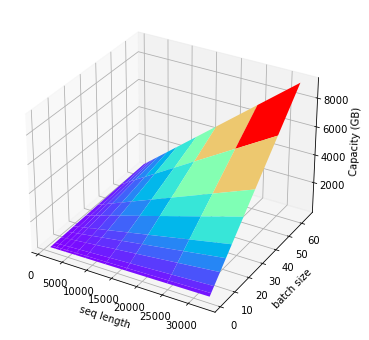

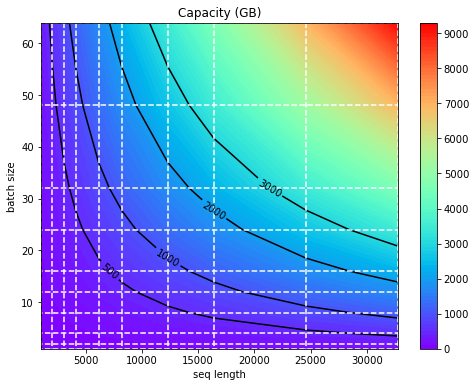

In [6]:
# Capacity
fig = plt.figure(figsize=(6,6))
ax3 = plt.axes(projection='3d')
ax3.plot_surface(list_x, list_y, cap_list, cmap='rainbow')
ax3.set_xlabel("seq length")
ax3.set_ylabel("batch size")
ax3.set_zlabel("Capacity (GB)")
plt.show()

# 
plt.figure(figsize=(8,6))
line = [500, 1000, 2000, 3000]

cset = plt.contourf(list_x, list_y, cap_list, 100, cmap='rainbow')
contour = plt.contour(list_x, list_y, cap_list, line, colors='k') # 加入等高线
plt.clabel(contour,fontsize=10,colors='k',fmt='%.0f')
# plot x
for max_token in max_token_list:
    plt.plot(2*[max_token], [0, 64], linestyle='--', color='w')
# plot y
for batchsize in batchsize_list:
    plt.plot([0, 32768], 2*[batchsize], linestyle='--', color='w')
plt.xlim((1024, 32768))
plt.ylim((1, 64))
plt.xlabel("seq length")
plt.ylabel("batch size")
plt.title("Capacity (GB)")
plt.colorbar(cset)
plt.show()

In [7]:
# Convert to contourf
token_per_sec_list = np.array(token_per_sec_list)
token_per_sec_list = token_per_sec_list.reshape(len(max_token_list), len(batchsize_list))
token_per_sec_list = token_per_sec_list.T

token_per_sec_batch_list = np.array(token_per_sec_batch_list)
token_per_sec_batch_list = token_per_sec_batch_list.reshape(len(max_token_list), len(batchsize_list))
token_per_sec_batch_list = token_per_sec_batch_list.T

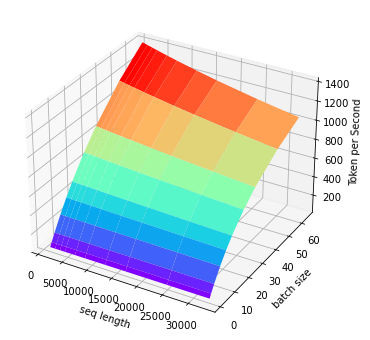

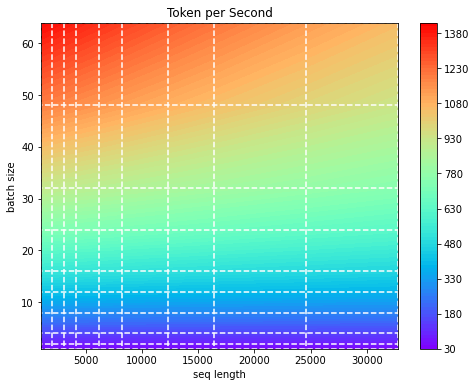

In [8]:
fig = plt.figure(figsize=(6,6))
ax3 = plt.axes(projection='3d')
ax3.plot_surface(list_x, list_y, token_per_sec_list, cmap='rainbow')
ax3.set_xlabel("seq length")
ax3.set_ylabel("batch size")
ax3.set_zlabel("Token per Second")
plt.show()

plt.figure(figsize=(8,6))
line = [64, 96, 128, 160, 256]

cset = plt.contourf(list_x, list_y, token_per_sec_list, 100, cmap='rainbow')
# contour = plt.contour(list_x, list_y, token_per_sec_list, line, colors='k') # 加入等高线
# plt.clabel(contour,fontsize=10,colors='k',fmt='%.0f')
# plot x
for max_token in max_token_list:
    plt.plot(2*[max_token], [0, 64], linestyle='--', color='w')
# plot y
for batchsize in batchsize_list:
    plt.plot([0, 32768], 2*[batchsize], linestyle='--', color='w')
plt.xlim((1024, 32768))
plt.ylim((1, 64))
plt.xlabel("seq length")
plt.ylabel("batch size")
plt.title("Token per Second")
plt.colorbar(cset)
plt.show()

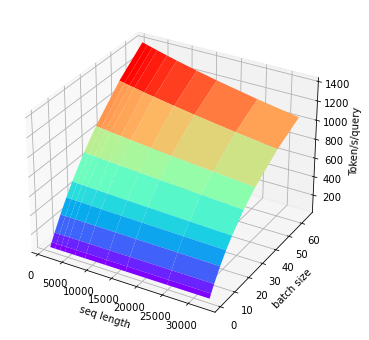

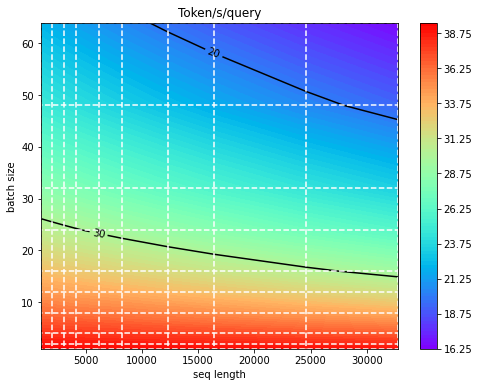

In [9]:
fig = plt.figure(figsize=(6,6))
ax3 = plt.axes(projection='3d')
ax3.plot_surface(list_x, list_y, token_per_sec_list, cmap='rainbow')
ax3.set_xlabel("seq length")
ax3.set_ylabel("batch size")
ax3.set_zlabel("Token/s/query")
plt.show()

plt.figure(figsize=(8,6))
line = [20, 30, 40]

cset = plt.contourf(list_x, list_y, token_per_sec_batch_list, 100, cmap='rainbow')
contour = plt.contour(list_x, list_y, token_per_sec_batch_list, line, colors='k') # 加入等高线
plt.clabel(contour,fontsize=10,colors='k',fmt='%.0f')
# plot x
for max_token in max_token_list:
    plt.plot(2*[max_token], [0, 64], linestyle='--', color='w')
# plot y
for batchsize in batchsize_list:
    plt.plot([0, 32768], 2*[batchsize], linestyle='--', color='w')
plt.xlim((1024, 32768))
plt.ylim((1, 64))
plt.xlabel("seq length")
plt.ylabel("batch size")
plt.title("Token/s/query")
plt.colorbar(cset)
plt.show()

In [ ]:
# Ratio = 0.9

In [10]:
bw_list = []
cap_list = []
token_per_sec_list = []
token_per_sec_batch_list = []
for max_token in max_token_list:
    for batchsize in batchsize_list:
        print("Max_token: {}; Batchsize: {}".format(max_token, batchsize))
        comb_hard = {
            "Name":"A100*8+PIMv1*1", 
            "PRF":{"hard":"A100", "quant":8},  # V100, A100, H100
            "GNR-PRJ":{"hard":"A100", "quant":8}, 
            "GNR-ACT":{"hard":"PIMv1", "quant":1}, 
            "Assign":"PRF+GNR-PRJ, GNR-ACT"
        }
        bw, cap, token_per_sec, token_per_sec_batch = cal_ts_pim(comb_hard=comb_hard, batchsize=batchsize, model=model, ratio_p=ratio_p, max_token=max_token, ratio_token=0.9, fig=False)
        bw_list.append(bw)
        cap_list.append(cap)
        token_per_sec_list.append(token_per_sec)
        token_per_sec_batch_list.append(token_per_sec_batch)

Max_token: 1024; Batchsize: 1
Name: A100x8_baseline, token per sec: 50, token per sec per batch: 50

Model: GPT3.5, BatchSize: 1
Need XPU: 324.0GB | XPU capacity: 640GB
Need PIM: 4.5GB | PIM capacity: 4.5GB

The max perf is 49 token/s (TFLOPS: 503, BW: 503TB/s)
Max_token: 1024; Batchsize: 2
Name: A100x8_baseline, token per sec: 99, token per sec per batch: 49

Model: GPT3.5, BatchSize: 2
Need XPU: 324.0GB | XPU capacity: 640GB
Need PIM: 9.0GB | PIM capacity: 9.0GB

The max perf is 97 token/s (TFLOPS: 503, BW: 503TB/s)
Max_token: 1024; Batchsize: 4
Name: A100x8_baseline, token per sec: 194, token per sec per batch: 48

Model: GPT3.5, BatchSize: 4
Need XPU: 324.0GB | XPU capacity: 640GB
Need PIM: 18.0GB | PIM capacity: 18.0GB

The max perf is 190 token/s (TFLOPS: 503, BW: 503TB/s)
Max_token: 1024; Batchsize: 8
Name: A100x8_baseline, token per sec: 372, token per sec per batch: 46

Model: GPT3.5, BatchSize: 8
Need XPU: 324.0GB | XPU capacity: 640GB
Need PIM: 36.0GB | PIM capacity: 36.0GB


The max perf is 907 token/s (TFLOPS: 503, BW: 503TB/s)
The 0.9 perf is 817 token/s (TFLOPS: 58.67, BW: 58.67TB/s)
Max_token: 3072; Batchsize: 32
Name: A100x8_baseline, token per sec: 848, token per sec per batch: 26

Model: GPT3.5, BatchSize: 32
Need XPU: 324.0GB | XPU capacity: 640GB
Need PIM: 432.0GB | PIM capacity: 432.0GB

The max perf is 1120 token/s (TFLOPS: 503, BW: 503TB/s)
The 0.9 perf is 1008 token/s (TFLOPS: 70.29, BW: 70.29TB/s)
Max_token: 3072; Batchsize: 48
Name: A100x8_baseline, token per sec: 1027, token per sec per batch: 21

Model: GPT3.5, BatchSize: 48
Need XPU: 324.0GB | XPU capacity: 640GB
Need PIM: 648.0GB | PIM capacity: 648.0GB

The max perf is 1462 token/s (TFLOPS: 503, BW: 503TB/s)
The 0.9 perf is 1316 token/s (TFLOPS: 87.64, BW: 87.64TB/s)
Max_token: 3072; Batchsize: 64
Name: A100x8_baseline, token per sec: 1148, token per sec per batch: 18

Model: GPT3.5, BatchSize: 64
Need XPU: 324.0GB | XPU capacity: 640GB
Need PIM: 864.0GB | PIM capacity: 864.0GB

The max

The max perf is 188 token/s (TFLOPS: 503, BW: 503TB/s)
The 0.9 perf is 169 token/s (TFLOPS: 34.44, BW: 34.44TB/s)
Max_token: 8192; Batchsize: 8
Name: A100x8_baseline, token per sec: 257, token per sec per batch: 32

Model: GPT3.5, BatchSize: 8
Need XPU: 324.0GB | XPU capacity: 640GB
Need PIM: 288.0GB | PIM capacity: 288.0GB

The max perf is 357 token/s (TFLOPS: 503, BW: 503TB/s)
The 0.9 perf is 321 token/s (TFLOPS: 61.09, BW: 61.09TB/s)
Max_token: 8192; Batchsize: 12
Name: A100x8_baseline, token per sec: 326, token per sec per batch: 27

Model: GPT3.5, BatchSize: 12
Need XPU: 324.0GB | XPU capacity: 640GB
Need PIM: 432.0GB | PIM capacity: 432.0GB

The max perf is 508 token/s (TFLOPS: 503, BW: 503TB/s)
The 0.9 perf is 457 token/s (TFLOPS: 82.37, BW: 82.37TB/s)
Max_token: 8192; Batchsize: 16
Name: A100x8_baseline, token per sec: 376, token per sec per batch: 24

Model: GPT3.5, BatchSize: 16
Need XPU: 324.0GB | XPU capacity: 640GB
Need PIM: 576.0GB | PIM capacity: 576.0GB

The max perf is

The max perf is 1027 token/s (TFLOPS: 503, BW: 503TB/s)
The 0.9 perf is 925 token/s (TFLOPS: 215.21, BW: 215.21TB/s)
Max_token: 16384; Batchsize: 48
Name: A100x8_baseline, token per sec: 312, token per sec per batch: 6

Model: GPT3.5, BatchSize: 48
Need XPU: 324.0GB | XPU capacity: 640GB
Need PIM: 3456.0GB | PIM capacity: 3456.0GB

The max perf is 1308 token/s (TFLOPS: 503, BW: 503TB/s)
The 0.9 perf is 1178 token/s (TFLOPS: 242.82, BW: 242.82TB/s)
Max_token: 16384; Batchsize: 64
Name: A100x8_baseline, token per sec: 322, token per sec per batch: 5

Model: GPT3.5, BatchSize: 64
Need XPU: 324.0GB | XPU capacity: 640GB
Need PIM: 4608.0GB | PIM capacity: 4608.0GB

The max perf is 1516 token/s (TFLOPS: 503, BW: 503TB/s)
The 0.9 perf is 1364 token/s (TFLOPS: 259.47, BW: 259.47TB/s)
Max_token: 24576; Batchsize: 1
Name: A100x8_baseline, token per sec: 42, token per sec per batch: 42

Model: GPT3.5, BatchSize: 1
Need XPU: 324.0GB | XPU capacity: 640GB
Need PIM: 108.0GB | PIM capacity: 108.0GB



In [11]:
# Convert to contourf
list_x, list_y = np.meshgrid(max_token_list, batchsize_list)
bw_list = np.array(bw_list)
bw_list = bw_list.reshape(len(max_token_list), len(batchsize_list))
bw_list = bw_list.T
cap_list = np.array(cap_list)
cap_list = cap_list.reshape(len(max_token_list), len(batchsize_list))
cap_list = cap_list.T

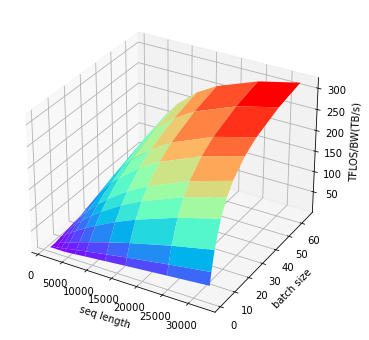

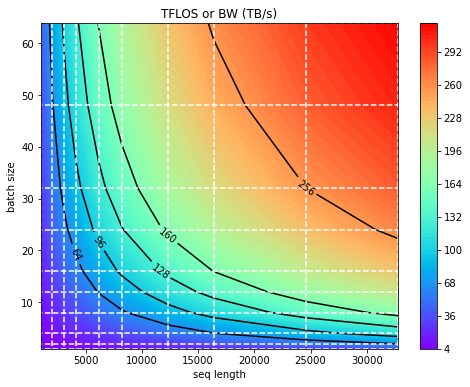

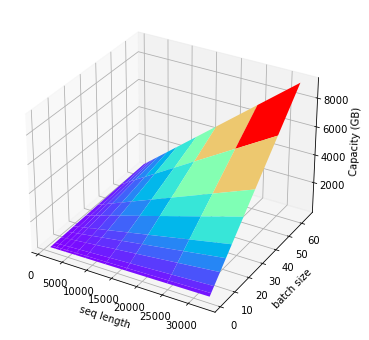

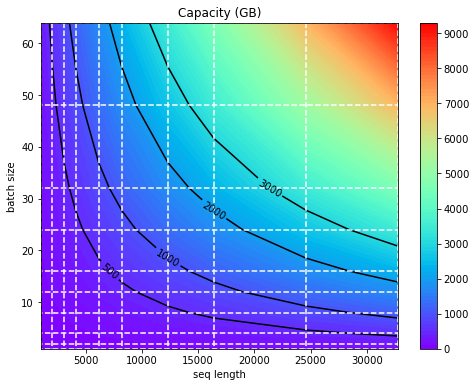

In [12]:
# TFLOS & BW
fig = plt.figure(figsize=(6,6))
ax3 = plt.axes(projection='3d')
ax3.plot_surface(list_x, list_y, bw_list, cmap='rainbow')
ax3.set_xlabel("seq length")
ax3.set_ylabel("batch size")
ax3.set_zlabel("TFLOS/BW(TB/s)")
plt.show()

plt.figure(figsize=(8,6))
line = [64, 96, 128, 160, 256]

cset = plt.contourf(list_x, list_y, bw_list, 100, cmap='rainbow')
contour = plt.contour(list_x, list_y, bw_list, line, colors='k') # 加入等高线
plt.clabel(contour,fontsize=10,colors='k',fmt='%.0f')
# plot x
for max_token in max_token_list:
    plt.plot(2*[max_token], [0, 64], linestyle='--', color='w')
# plot y
for batchsize in batchsize_list:
    plt.plot([0, 32768], 2*[batchsize], linestyle='--', color='w')
plt.xlim((1024, 32768))
plt.ylim((1, 64))
plt.xlabel("seq length")
plt.ylabel("batch size")
plt.title("TFLOS or BW (TB/s)")
plt.colorbar(cset)
plt.show()

# Capacity
fig = plt.figure(figsize=(6,6))
ax3 = plt.axes(projection='3d')
ax3.plot_surface(list_x, list_y, cap_list, cmap='rainbow')
ax3.set_xlabel("seq length")
ax3.set_ylabel("batch size")
ax3.set_zlabel("Capacity (GB)")
plt.show()

# 
plt.figure(figsize=(8,6))
line = [500, 1000, 2000, 3000]

cset = plt.contourf(list_x, list_y, cap_list, 100, cmap='rainbow')
contour = plt.contour(list_x, list_y, cap_list, line, colors='k') # 加入等高线
plt.clabel(contour,fontsize=10,colors='k',fmt='%.0f')
# plot x
for max_token in max_token_list:
    plt.plot(2*[max_token], [0, 64], linestyle='--', color='w')
# plot y
for batchsize in batchsize_list:
    plt.plot([0, 32768], 2*[batchsize], linestyle='--', color='w')
plt.xlim((1024, 32768))
plt.ylim((1, 64))
plt.xlabel("seq length")
plt.ylabel("batch size")
plt.title("Capacity (GB)")
plt.colorbar(cset)
plt.show()

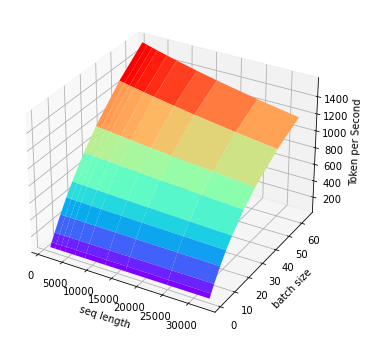

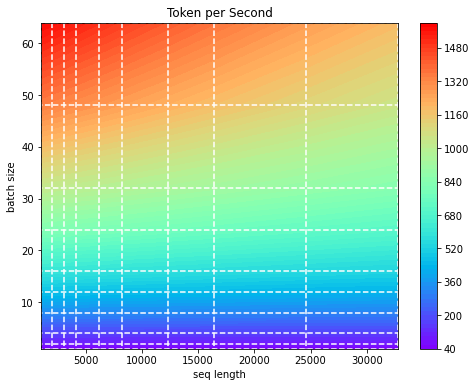

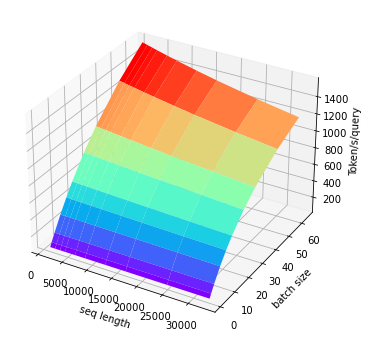

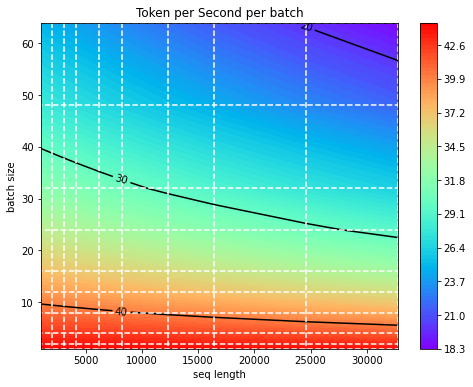

In [13]:
# Convert to contourf
token_per_sec_list = np.array(token_per_sec_list)
token_per_sec_list = token_per_sec_list.reshape(len(max_token_list), len(batchsize_list))
token_per_sec_list = token_per_sec_list.T

token_per_sec_batch_list = np.array(token_per_sec_batch_list)
token_per_sec_batch_list = token_per_sec_batch_list.reshape(len(max_token_list), len(batchsize_list))
token_per_sec_batch_list = token_per_sec_batch_list.T

# Token per sec
fig = plt.figure(figsize=(6,6))
ax3 = plt.axes(projection='3d')
ax3.plot_surface(list_x, list_y, token_per_sec_list, cmap='rainbow')
ax3.set_xlabel("seq length")
ax3.set_ylabel("batch size")
ax3.set_zlabel("Token per Second")
plt.show()

plt.figure(figsize=(8,6))
line = [64, 96, 128, 160, 256]

cset = plt.contourf(list_x, list_y, token_per_sec_list, 100, cmap='rainbow')
# contour = plt.contour(list_x, list_y, token_per_sec_list, line, colors='k') # 加入等高线
# plt.clabel(contour,fontsize=10,colors='k',fmt='%.0f')
# plot x
for max_token in max_token_list:
    plt.plot(2*[max_token], [0, 64], linestyle='--', color='w')
# plot y
for batchsize in batchsize_list:
    plt.plot([0, 32768], 2*[batchsize], linestyle='--', color='w')
plt.xlim((1024, 32768))
plt.ylim((1, 64))
plt.xlabel("seq length")
plt.ylabel("batch size")
plt.title("Token per Second")
plt.colorbar(cset)
plt.show()

# Token/s/query
fig = plt.figure(figsize=(6,6))
ax3 = plt.axes(projection='3d')
ax3.plot_surface(list_x, list_y, token_per_sec_list, cmap='rainbow')
ax3.set_xlabel("seq length")
ax3.set_ylabel("batch size")
ax3.set_zlabel("Token/s/query")
plt.show()

plt.figure(figsize=(8,6))
line = [20, 30, 40]

cset = plt.contourf(list_x, list_y, token_per_sec_batch_list, 100, cmap='rainbow')
contour = plt.contour(list_x, list_y, token_per_sec_batch_list, line, colors='k') # 加入等高线
plt.clabel(contour,fontsize=10,colors='k',fmt='%.0f')
# plot x
for max_token in max_token_list:
    plt.plot(2*[max_token], [0, 64], linestyle='--', color='w')
# plot y
for batchsize in batchsize_list:
    plt.plot([0, 32768], 2*[batchsize], linestyle='--', color='w')
plt.xlim((1024, 32768))
plt.ylim((1, 64))
plt.xlabel("seq length")
plt.ylabel("batch size")
plt.title("Token per Second per batch")
plt.colorbar(cset)
plt.show()